# Дослідження 06 — Сегментація, кейси та дорожня карта

1. Основне завдання
    1. **Сегментація**: Візьміть зображення з кількома об'єктами, запустіть YOLO-seg, обчисліть площу кожного знайденого об'єкта в пікселях і відобразіть маску найбільшого з них як overlay. Порівняйте bbox і маску для нього.
2. Додаткова практика
    1. запустіть **бенчмарк FP32 vs ONNX** з ноутбука і зафіксуйте speedup на вашому середовищі;
    2. спробуйте **SAM з point prompt** на одному зображенні (потрібно завантажити ваги ~375 MB);
    3. опишіть CV-задачу для свого домену за структурою з ноутбука: що детектувати, звідки дані, cloud чи edge, метрика успіху, основний ризик.

## Інсталяція залежностей


In [1]:
import importlib.util
import subprocess
import sys


def ensure_packages(packages):
    """Встановлює пакети, тільки якщо їх ще немає (працює і локально, і в Colab)."""
    missing = [
        pkg for pkg, mod in packages.items() if importlib.util.find_spec(mod) is None
    ]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


# ключ — назва для pip install, значення — назва модуля для import
ensure_packages(
    {
        "ultralytics": "ultralytics",
        "opencv-python": "opencv-python",
        "matplotlib": "matplotlib",
        "onnxruntime-gpu": "onnxruntime",
        "segment-anything": "segment-anything",
    }
)


print("Python:", sys.version)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"
print("Device:", device)

TEST_IMG = "https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg?rlkey=19z4ecwes9bfs6b2k5jbrx4sx&st=rhp22k76&raw=1"

Python: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
Device: 0


## Основне завдання - Сегментація
_Візьміть зображення з кількома об'єктами, запустіть YOLO-seg, обчисліть площу кожного знайденого об'єкта в пікселях і відобразіть маску найбільшого з них як overlay. Порівняйте bbox і маску для нього._

Робимо виклик моделі YOLO-seg для тестового зображення ![тестове зображення](https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg?rlkey=19z4ecwes9bfs6b2k5jbrx4sx&st=rhp22k76&raw=1)

Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg


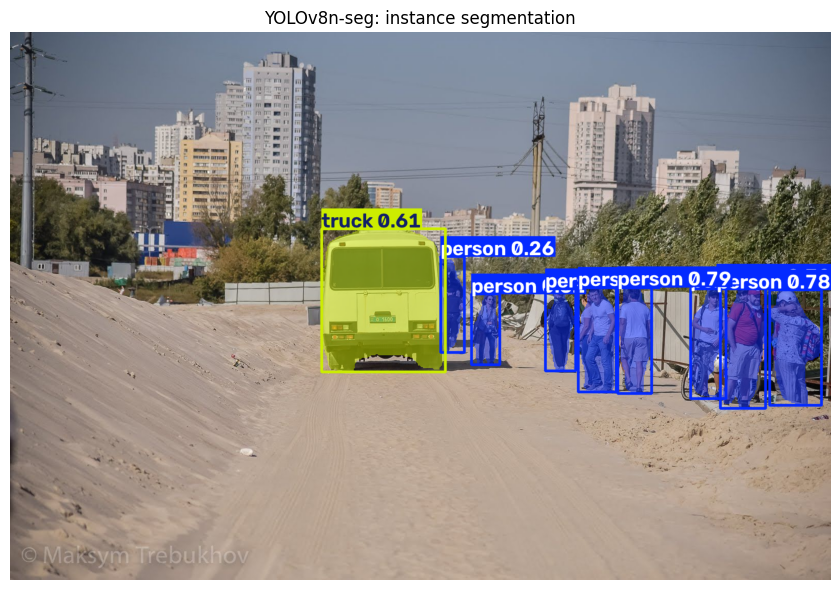

Об'єктів знайдено: 9


In [2]:
def show(img, title=None, bgr=False, figsize=(10, 6)):
    if bgr:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# YOLO-seg: instance segmentation одним рядком
model_seg = YOLO("yolov8n-seg.pt")

results = model_seg.predict(source=TEST_IMG, conf=0.25, device=device, verbose=False)
r = results[0]

# Відображення з масками
annotated = r.plot()
show(annotated, "YOLOv8n-seg: instance segmentation", bgr=True)

# переконаймося, що знайдено кілька об'єктів
print("Об'єктів знайдено:", len(r.masks))

Обчислення площі кожної маски

In [3]:
areas = []
for i, mask in enumerate(r.masks.data):
    cls_id = int(r.boxes.cls[i])  # номер класса (число)
    class_name = r.names[cls_id]  # r.names - словарь {0: 'person', 5: 'bus', ...}
    
    # ресайз маски до розміру оригіналу ПЕРЕД підрахунком площі
    mask_np = mask.cpu().numpy().astype(np.uint8)
    h, w = r.orig_img.shape[:2]
    mask_resized = cv2.resize(mask_np, (w, h), interpolation=cv2.INTER_NEAREST)
    
    area_px = int(mask_resized.sum())
    areas.append(area_px)
    conf = r.boxes.conf[i].item()
    print(f"{class_name}: area={area_px}px, conf={conf:.2f}")

print(max(areas))

person: area=9841px, conf=0.79
person: area=13958px, conf=0.78
person: area=11417px, conf=0.74
person: area=14155px, conf=0.72
person: area=5489px, conf=0.69
truck: area=56048px, conf=0.61
person: area=9516px, conf=0.59
person: area=5000px, conf=0.52
person: area=6158px, conf=0.26
56048


Знаходження найбільшого об'єкта

`idx_max = argmax(areas)`
Витягни для нього: клас, confidence, bbox (`r.boxes.xyxy[idx_max]`), маску (`r.masks.data[idx_max]`)

In [4]:
idx_max = np.argmax(areas)
cls_id_max = int(r.boxes.cls[idx_max])  # правильний id класа саме цього об'єкта
print("Індекс елемента з максимальною площею:", idx_max,)
print("його площа: ", areas[idx_max], "px")

Індекс елемента з максимальною площею: 5
його площа:  56048 px


Отримання для найбільшого об'єкта:
- назви класу;
- confidence;
- bbox;
- маски.

In [5]:
print("Властивості найбільшого класіфікованого на фото об'єку:")
print("  Назва класу:", r.names[cls_id_max])
print("  confidence:", r.boxes.conf[idx_max].item())
print("  bbox:", r.boxes.xyxy[idx_max])
print("  маска:", r.masks.data[idx_max])

maxobj_class_name = r.names[cls_id_max]
maxobj_confidence = r.boxes.conf[idx_max].item()
maxobj_bbox = r.boxes.xyxy[idx_max]
maxobj_mask = r.masks.data[idx_max]

Властивості найбільшого класіфікованого на фото об'єку:
  Назва класу: truck
  confidence: 0.6054332256317139
  bbox: tensor([607.7166, 383.3278, 848.5068, 662.7522], device='cuda:0')
  маска: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0', dtype=torch.uint8)


Overlay маски найбільшого об'єкта

In [6]:
maxobj_mask_np = maxobj_mask.cpu().numpy()
maxobj_mask_binary = maxobj_mask_np.astype(np.uint8)
print(maxobj_mask_np.shape, r.orig_img.shape[:2])

# colored_mask = якийсь колір там, де mask_binary == 1
# overlay = cv2.addWeighted(orig_img, 1-alpha, colored_mask, alpha, 0)

(448, 640) (1068, 1600)


Розміри масок не збігаються (маска менше: 448 640 проти 1068 1600 у оригіналу). Це стандартна поведінка YOLO - маски вважаються на зменшеному внутрішньому дозволі моделі, а не на оригіналі.

Потрібно вирішити маску до розміру оригіналу перед overlay:

In [7]:
h, w = r.orig_img.shape[:2]  # (1068, 1600) - висота, ширина

maxobj_mask_resized = cv2.resize(
    maxobj_mask_binary,
    (w, h),  # ВАЖЛИВО: cv2.resize приймає (width, height), а не (height, width)!
    interpolation=cv2.INTER_NEAREST,  # nearest, щоб не розмити бінарну маску
)

print(maxobj_mask_resized.shape)  # повинно стати (1068, 1600)

(1068, 1600)


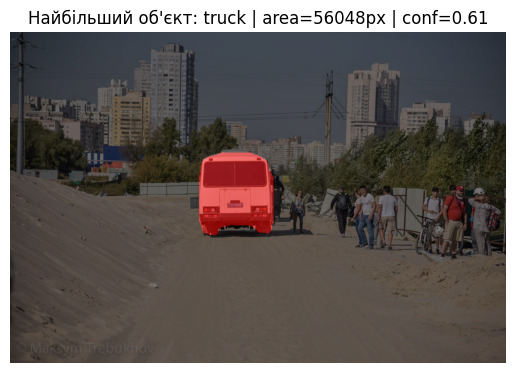

In [8]:
# Створюємо порожнє кольорове зображення того ж розміру, що оригінал
colored_mask = np.zeros_like(r.orig_img)  # shape (1068, 1600, 3), все нули
# задаємо колір (BGR, тому що працюємо в OpenCV) - наприклад, червоний
color = (0, 0, 255)  # B, G, R
colored_mask[maxobj_mask_resized == 1] = color  # фарбуємо тільки там, де маска == 1

alpha = 0.5
overlay = cv2.addWeighted(r.orig_img, 1 - alpha, colored_mask, alpha, 0)

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
plt.imshow(overlay_rgb)
plt.title(
    f"Найбільший об'єкт: {maxobj_class_name} | area={areas[idx_max]}px | conf={maxobj_confidence:.2f}"
)
plt.axis("off")
plt.show()

Порівняння bbox vs маска для цього об'єкта

- На тому ж overlay або поруч (subplot) намалюй bbox (cv2.rectangle) навколо того ж об'єкта
- Візуально: скільки "зайвого" простору захоплює bbox, якого немає в масці (фон всередині прямокутника)
- Можна порахувати: `bbox_area = (x2-x1)*(y2-y1)`, порівняти з `area_px` маски — яка частка bbox дійсно належить об'єкту

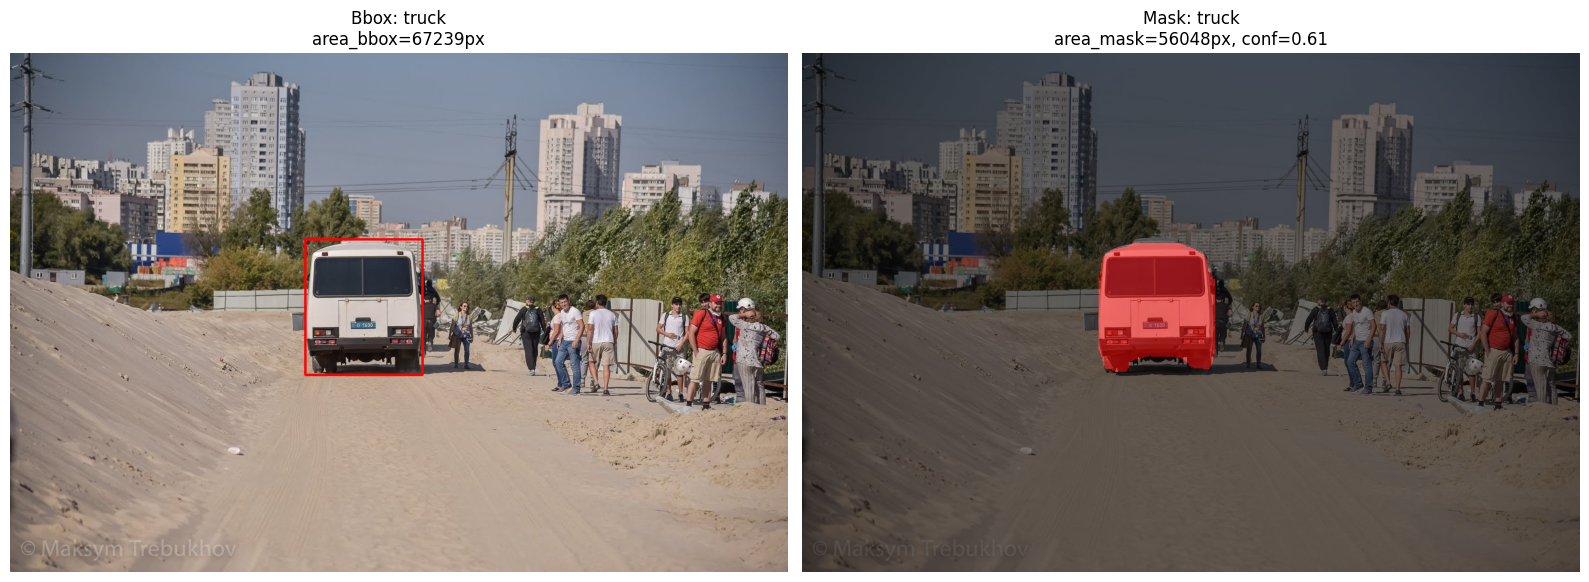

In [9]:
# 1. Готуємо картинку с bbox
bbox_img = r.orig_img.copy()
x1, y1, x2, y2 = map(int, r.boxes.xyxy[idx_max])
cv2.rectangle(bbox_img, (x1, y1), (x2, y2), color=(0, 0, 255), thickness=3)
bbox_rgb = cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)

bbox_area = (x2 - x1) * (y2 - y1)

# 2. Виводимо bbox та mask поруч
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(bbox_rgb)
axes[0].set_title(f"Bbox: {maxobj_class_name}\narea_bbox={bbox_area}px")
axes[0].axis("off")

axes[1].imshow(overlay_rgb)
axes[1].set_title(
    f"Mask: {maxobj_class_name}\narea_mask={areas[idx_max]}px, conf={maxobj_confidence:.2f}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [10]:
fill_ratio = 56048 / 67239 * 100
print(f"Маска займає ~ {int(fill_ratio)}% площі bbox")

Маска займає ~ 83% площі bbox


### **_Висновки по основному завданню_**

**Найбільший об'єкт на фото:** truck (мікроавтобус), confidence=0.61

| Метрика | Значення |
|---|---|
| Площа bbox | 67 239 px |
| Площа маски | 56 048 px |
| Заповненість bbox маскою | ~83.4% |

#### _**Bbox vs маска**_

Для цього конкретного об'єкта (мікроавтобус, знятий строго ззаду) bbox і маска
виявились доволі близькими за площею — прямокутна форма кузова добре
"вписується" у прямокутний bbox, тому різниця складає лише ~17%. Це підтверджує
загальну закономірність: **чим ближче форма об'єкта до прямокутника, тим менше
bbox переоцінює його реальну площу**. Для об'єктів неправильної форми
(наприклад, людина з розкинутими руками чи велосипедист) різниця була б значно
більшою, оскільки bbox все одно змушений охоплювати весь об'єкт по ширині й
висоті, захоплюючи багато зайвого фону.

#### **_Технічні нюанси, з якими зіткнувся під час виконання_**

1. **Плутанина індексу позиції з id класу.** Спроба взяти назву класу як
   `r.names[idx_max]` (де `idx_max` - порядковий номер об'єкта в списку
   результатів) дала неправильний клас (`bus` замість `truck`) - випадковий
   збіг чисел. Правильний спосіб - спочатку дістати `cls_id = int(r.boxes.cls[idx_max])`,
   і вже потім `r.names[cls_id]`.

2. **Невідповідність розмірів маски та оригіналу.** Маски, які повертає
   `model.predict()`, мають розмір внутрішнього робочого розрізнення моделі
   (у цьому випадку `448×640`), а не розмір оригінального зображення
   (`1068×1600`). Підрахунок площі маски "як є" дав хибно занижене число
   (9 401 px замість реальних ~56 000 px) - площу потрібно рахувати **після**
   `cv2.resize(..., interpolation=cv2.INTER_NEAREST)` до розміру оригіналу.

#### _**Загальний висновок**_

_Сегментація дає значно точнішу оцінку площі об'єкта, ніж bounding box,
особливо для об'єктів складної форми. Навіть для відносно "прямокутного"
об'єкта різниця сягає ~17%, а для об'єктів неправильної форми вона зазвичай
набагато більша. Це ключова перевага instance segmentation над звичайною
детекцією там, де важлива саме форма чи точна площа об'єкта (підрахунок
матеріалів, оцінка розміру ушкоджень, медичні застосування тощо)._

## SAM point prompt на тому ж об'єкті

- _Розкоментувати скелет із ячейки 11, підставити реальну точку (центр bbox найбільшого об'єкта, наприклад)_
- _Порівняти SAM-маску з YOLO-seg маскою того ж об'єкта (площа, форма)_

In [11]:
# Завантаження вагів ViT-B (найлешний варіант)
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-09-15 03:23:53--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.244.102.73, 18.244.102.64, 18.244.102.110, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.244.102.73|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: 'sam_vit_b_01ec64.pth.10'

     0K .......... .......... .......... .......... ..........  0% 3,30M 1m48s
    50K .......... .......... .......... .......... ..........  0% 3,01M 1m54s
   100K .......... .......... .......... .......... ..........  0% 6,01M 96s
   150K .......... .......... .......... .......... ..........  0% 6,10M 86s
   200K .......... .......... .......... .......... ..........  0% 10,0M 76s
   250K .......... .......... .......... .......... ..........  0% 11,6M 69s
   300K .......... .......... .......... .......... ..........  0% 11,7M 63s
   350K .......... ......

Завантажимо модель

In [12]:
from segment_anything import SamPredictor, sam_model_registry

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(r.orig_img)  # той самий кадр, що і в завданні А


Point prompt - координати точкі
SAM чекає на точку всередині об'єкта, не bbox. Логічно взяти центр bbox автобуса, яку ми вже знайшли в основному завданні

In [13]:
x1, y1, x2, y2 = map(int, r.boxes.xyxy[idx_max])  # bbox truck
point_x = (x1 + x2) // 2
point_y = (y1 + y2) // 2

input_point = np.array([[point_x, point_y]])
input_label = np.array([1])  # 1 = foreground point (це точка "всередині об'єкта")

In [14]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,  # SAM поверне кілька варіантів маски з різною "детальністю"
)


Порівняння з YOLO-seg маской

In [15]:
best_idx = np.argmax(scores)
sam_mask = masks[best_idx]
sam_area = sam_mask.sum()

print(f"YOLO-seg area: {areas[idx_max]}px")
print(f"SAM area: {sam_area}px")


YOLO-seg area: 56048px
SAM area: 6670px


mask 0: score=0.861, area=58668px
mask 1: score=0.882, area=6670px
mask 2: score=0.799, area=3851px
[[727 522]]


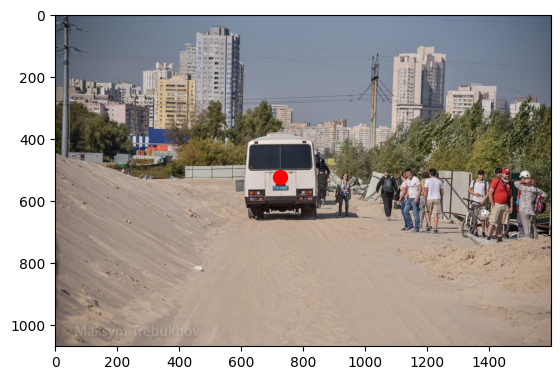

In [16]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    print(f"mask {i}: score={score:.3f}, area={mask.sum()}px")

print(input_point)  # (point_x, point_y)
plt.imshow(cv2.cvtColor(r.orig_img, cv2.COLOR_BGR2RGB))
plt.scatter(input_point[0][0], input_point[0][1], c="red", s=100)
plt.show()

Бачимо класичну проблему point prompt без додаткового контексту: SAM не знає, що саме малося на увазі під "всім об’єктом" - вона просто шукає будь-яку зв’язну область навколо точки з чіткими межами, і деталь (скло) для неї виглядає навіть "більш переконливо", ніж цілий об’єкт.

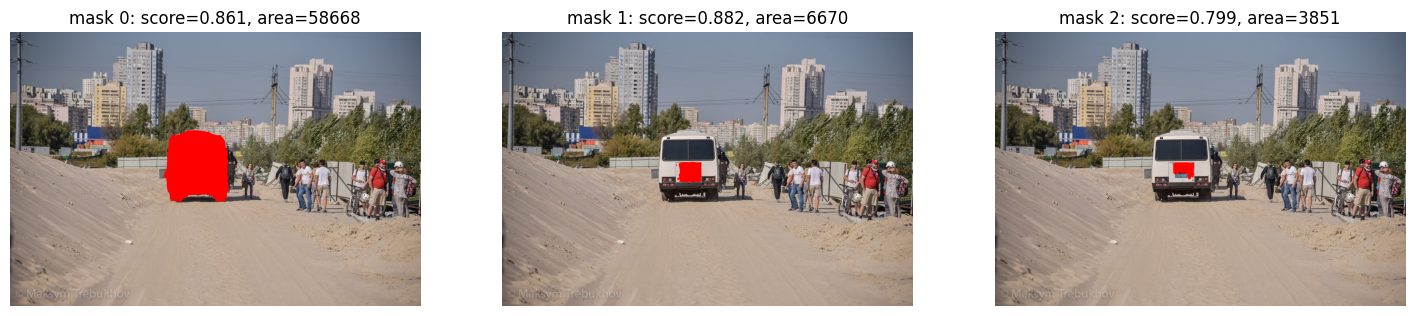

In [17]:
# подивимося візуально на всі три маски, щоб переконатись
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, mask in enumerate(masks):
    overlay = r.orig_img.copy()
    overlay[mask] = (0, 0, 255)
    axes[i].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"mask {i}: score={scores[i]:.3f}, area={mask.sum()}")
    axes[i].axis('off')
plt.show()

#### SAM з point prompt

Точку (координати центру bbox truck: `[727, 522]`) було задано для SAM без додаткового контексту (лише одна foreground-точка). Точка потрапила на темне
заднє скло автобуса - контрастну, чітко окреслену деталь.

SAM повернула 3 варіанти маски:

| Маска | Score | Площа (px) | Що це |
|---|---|---|---|
| mask 0 | 0.861 | 58 668 | Весь автобус |
| mask 1 | 0.882 | 6 670 | Заднє скло (найвищий score) |
| mask 2 | 0.799 | 3 851 | Ще дрібніша деталь |

**Ключове спостереження:** маска з найвищим score (`argmax(scores)`) - **не** маска всього об'єкта. SAM оцінює якість/чіткість меж, а не те, наскільки повно маска покриває об'єкт. Контрастна дрібна деталь (скло) отримала вищий score, ніж весь автобус, через чіткіші межі.

**Порівняння з YOLO-seg (правильна маска, mask 0):**

| | YOLO-seg | SAM (mask 0) |
|---|---|---|
| Площа | 56 048 px | 58 668 px |
| Різниця | - | ~4.7% |

Площі виявились дуже близькими (~5% розбіжність) - обидва підходи дали
практично однакову оцінку площі об'єкта, коли SAM отримала правильну маску.

### _**Висновок про SAM point prompt**_
_для надійного результату недостатньо взяти маску з `argmax(scores)` наосліп - потрібно або перевіряти площу/форму візуально, або клікати в "нейтральну" зону об'єкта (центр кузова, а не контрастні деталі на кшталт скла/фар), або використовувати кілька точок (включно з negative points) для однозначної вказівки на весь об'єкт._

## Додаткове завдання - бенчмарк FP32 vs ONNX
_Запустіть бенчмарк FP32 vs ONNX з ноутбука і зафіксуйте speedup на вашому середовищі_

In [18]:
import time

model_fp32 = YOLO("yolov8n.pt")

import numpy as np


def benchmark(model, source, n=30, warmup=5, desc=""):
    for _ in range(warmup):
        model.predict(source=source, conf=0.25, device=device, verbose=False)

    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        model.predict(source=source, conf=0.25, device=device, verbose=False)
        times.append((time.perf_counter() - t0) * 1000)

    median = np.median(times)
    print(f"{desc:<20} median: {median:.1f}ms ({1000 / median:.0f} FPS)")
    return median

t_fp32 = benchmark(model_fp32, TEST_IMG, desc="YOLOv8n FP32")

export_path = model_fp32.export(format="onnx", half=torch.cuda.is_available())
model_onnx = YOLO(export_path)
t_onnx = benchmark(model_onnx, TEST_IMG, desc="YOLOv8n ONNX")

print(f"\nONNX speedup: {t_fp32 / t_onnx:.2f}x")


Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd0xklhd13mpdirx4vae/_MAX5392.jpg locally at _MAX5392.jpg
Found https://www.dropbox.com/scl/fi/mhd

### Бенчмарк FP32 vs ONNX

Кілька незалежних прогонів (`n=30`, 5 прогонів warmup, медіана):

| Прогін | FP32 median | ONNX median | Speedup |
|---|---|---|---|
| 1 | 17.7 ms (57 FPS) | 16.1 ms (62 FPS) | 1.10x |
| 2 | 13.6 ms (73 FPS) | 15.7 ms (64 FPS) | 0.87x |

_**Висновок: різниця між FP32 та ONNX знаходиться в межах шуму вимірювання - жоден з варіантів не має стійкої переваги на цьому середовищі.**_
_
Це не артефакт поганої методології заміру - навіть з медіаною по 30 прогонах і повноцінним warmup результат перемикається між "ONNX швидше" та "FP32 швидше" від запуску до запуску. Причина - високий і нестабільний kernel launch overhead (WDDM-режим драйвера GeForce на Windows, підтверджено раніше чистим тестом одиночної conv-операції - ~2.4мс на просту операцію, що ненормально повільно для RTX 3060 Ti). Обидва бекенди (PyTorch CUDA та ONNX Runtime CUDAExecutionProvider) страждають від цього overhead приблизно однаково, тому їхня відносна швидкість залежить від дрібних коливань системного навантаження між запусками, а не від фундаментальної переваги одного формату над іншим.

На платформі з TCC-режимом (Quadro/Tesla) або на Linux (де WDDM-проблема відсутня) очікується значно менший overhead і, ймовірно, чіткіша та стійкіша перевага ONNX - це варто перевірити окремо, а саме в Google Collab версії цього ноутбука.

## Додаткове завдання: CV задача
_Опишіть CV-задачу для свого домену за структурою з ноутбука: що детектувати, звідки дані, cloud чи edge, метрика успіху, основний ризик._

In [19]:
my_cv_task = {
    "task": "Детекція UAV (дронів) та птахів у відеопотоці - 2 класи, "
    "мінімально відмінні за формою на дистанції (потрібно "
    "розрізняти дрон-загрозу від фонового шуму типу птахів)",
    "data_source": "FPV-відеозаписи дронів з Telegram-каналів (наразі це "
    "джерело для UAV-класу); для birds дані менш численні - "
    "мінорний клас, що й давало дисбаланс у HW-5. У продакшн "
    "варіанті знадобиться додатковий збір birds-кадрів "
    "(наприклад, з відкритих датасетів на кшталт "
    "CUB-200/NABirds чи власного знімання) для балансування",
    "deploy": "Edge — інференс на пристрої в реальному часі критичний "
    "(затримка cloud-роундтріпу неприйнятна для реагування "
    "на загрозу). Конкретна платформа ще не визначена (TBD) "
    "- розглядались варіанти на кшталт Rockchip NPU",
    "metric": "mAP@50, з окремим фокусом на recall мінорного класу "
    "(bird) - у HW-5 саме recall/AP для birds просідав через "
    "дисбаланс класів, тому це ключова метрика, а не "
    "загальний mAP",
    "risks": "Головний ризик - false negative на UAV (пропущена "
    "реальна загроза) через плутанину з birds на великій "
    "дистанції, коли обидва класи виглядають як дрібна темна "
    "цятка. Сценарій - дрон-до-дрона (детекція з борту "
    "дрона, а не наземне спостереження), тому додатковий "
    "ризик: нестабільний ракурс і сильна вібрація/рух камери "
    "самого дрона-спостерігача, що ускладнює стабільну "
    "детекцію порівняно зі статичною наземною камерою",
}

for k, v in my_cv_task.items():
    print(f"{k:>15}: {v}")


           task: Детекція UAV (дронів) та птахів у відеопотоці - 2 класи, мінімально відмінні за формою на дистанції (потрібно розрізняти дрон-загрозу від фонового шуму типу птахів)
    data_source: FPV-відеозаписи дронів з Telegram-каналів (наразі це джерело для UAV-класу); для birds дані менш численні - мінорний клас, що й давало дисбаланс у HW-5. У продакшн варіанті знадобиться додатковий збір birds-кадрів (наприклад, з відкритих датасетів на кшталт CUB-200/NABirds чи власного знімання) для балансування
         deploy: Edge — інференс на пристрої в реальному часі критичний (затримка cloud-роундтріпу неприйнятна для реагування на загрозу). Конкретна платформа ще не визначена (TBD) - розглядались варіанти на кшталт Rockchip NPU
         metric: mAP@50, з окремим фокусом на recall мінорного класу (bird) - у HW-5 саме recall/AP для birds просідав через дисбаланс класів, тому це ключова метрика, а не загальний mAP
          risks: Головний ризик - false negative на UAV (пропущена реальн

## CV-задача: детекція UAV та birds (дрон-до-дрона)

**Що детектувати:** UAV (дрони) та птахи у відеопотоці - 2 класи, мінімально відмінні за формою на дистанції; потрібно розрізняти дрон-загрозу від фонового шуму типу птахів.

**Дані:** FPV-відеозаписи дронів з Telegram-каналів (джерело для UAV-класу).
Для birds дані менш численні - мінорний клас, що й давало дисбаланс у HW-5. У продакшн варіанті знадобиться додатковий збір birds-кадрів (наприклад, з відкритих датасетів на кшталт CUB-200/NABirds чи власного знімання).

**Deploy:** Edge - інференс на пристрої в реальному часі критичний (затримка cloud-роундтріпу неприйнятна для реагування на загрозу). Конкретна платформа ще не визначена (TBD) - розглядались варіанти на кшталт Rockchip NPU.

**Метрика успіху:** mAP@50, з окремим фокусом на recall мінорного класу (bird) - саме recall/AP для birds просідав через дисбаланс класів у HW-5.

**Основний ризик:** false negative на UAV (пропущена реальна загроза) через плутанину з birds на великій дистанції. Сценарій - дрон-до-дрона (детекція
з борту дрона), тому додатковий ризик - нестабільний ракурс і вібрація/рух камери самого дрона-спостерігача.